# 3. Data plots and tables

\begin{table}[htbp]
\centering
\caption{Summary Statistics of German Zero-Coupon Yields}
\label{tab:summary_stats}
\begin{tabular}{lrrrrrrrr}
\hline\hline
Maturity & Mean & Std. Dev. & Min & Q25 & Median & Q75 & Max & N \\
\hline
1Y   & 0.015 & 0.018 & $-0.009$ & $-0.002$ & 0.015 & 0.030 & 0.051 & 6,986 \\
2Y   & 0.016 & 0.018 & $-0.010$ & $-0.002$ & 0.017 & 0.030 & 0.052 & 6,986 \\
3Y   & 0.017 & 0.018 & $-0.010$ & $-0.001$ & 0.019 & 0.030 & 0.052 & 6,986 \\
4Y   & 0.018 & 0.018 & $-0.010$ & $-0.001$ & 0.021 & 0.033 & 0.052 & 6,986 \\
5Y   & 0.019 & 0.018 & $-0.010$ & 0.000 & 0.022 & 0.035 & 0.053 & 6,986 \\
6Y   & 0.020 & 0.018 & $-0.010$ & 0.002 & 0.023 & 0.036 & 0.053 & 6,986 \\
7Y   & 0.021 & 0.018 & $-0.010$ & 0.003 & 0.023 & 0.037 & 0.055 & 6,986 \\
8Y   & 0.023 & 0.018 & $-0.009$ & 0.004 & 0.024 & 0.039 & 0.055 & 6,986 \\
9Y   & 0.023 & 0.018 & $-0.009$ & 0.005 & 0.025 & 0.039 & 0.056 & 6,986 \\
10Y  & 0.024 & 0.018 & $-0.009$ & 0.007 & 0.026 & 0.040 & 0.056 & 6,986 \\
12Y  & 0

C:\Users\westenb\AppData\Local\Temp\ipykernel_18356\2882630500.py:103: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


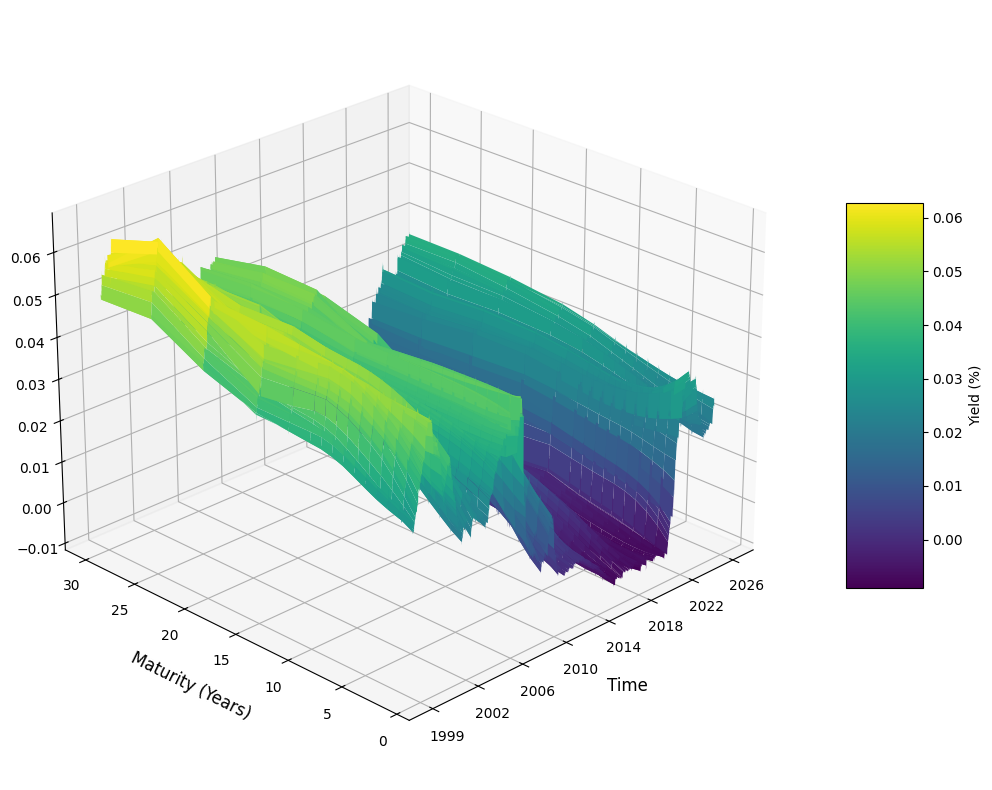

\begin{table}[htbp]
\centering
\caption{Summary Statistics of 3M$\,\times\,$10Y ATM Normal Swaption Implied Volatility}
\label{tab:iv_stats}
\begin{tabular}{lrrrrrrrr}
\hline\hline
Variable & Mean & Std. Dev. & Min & Q25 & Median & Q75 & Max & N \\
\hline
IV (bp) & 66.669 & 25.079 & 26.340 & 49.610 & 62.475 & 79.535 & 180.310 & 6,986 \\
\hline\hline
\end{tabular}
\end{table}


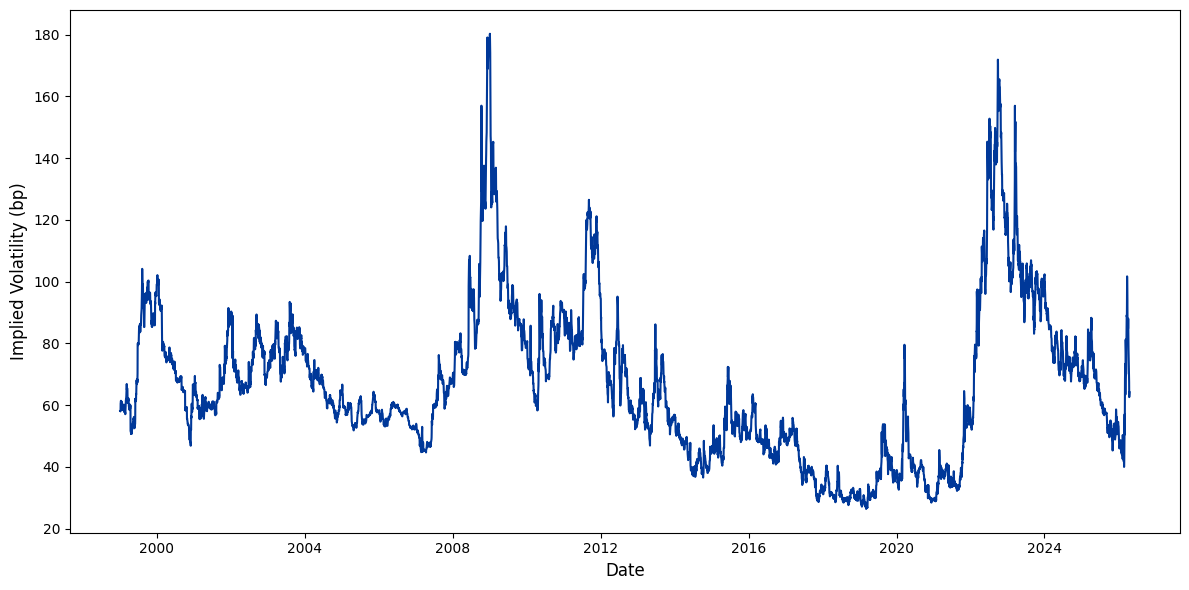

In [1]:
# ============================================
# ANALYSIS: YIELD CURVE & IV
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import os

# ============================================
# CONFIGURATION
# ============================================
MARKET = 'DE'
source_path = r"Data\Source"

zero_columns = ['ZERO_1Y', 'ZERO_2Y', 'ZERO_3Y', 'ZERO_4Y', 'ZERO_5Y',
                'ZERO_6Y', 'ZERO_7Y', 'ZERO_8Y', 'ZERO_9Y', 'ZERO_10Y',
                'ZERO_12Y', 'ZERO_15Y', 'ZERO_20Y', 'ZERO_25Y', 'ZERO_30Y']
maturities = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30]
maturity_labels = ['1Y','2Y','3Y','4Y','5Y','6Y','7Y','8Y','9Y','10Y',
                   '12Y','15Y','20Y','25Y','30Y']

# ============================================
# IMPORT
# ============================================

df_yc = pd.read_csv(os.path.join(source_path, f"{MARKET}_YieldCurve.csv"))
df_yc['REFERENCE_DATE'] = pd.to_datetime(df_yc['REFERENCE_DATE'])

df_iv = pd.read_csv(os.path.join(source_path, "IV.csv"))
df_iv['REFERENCE_DATE'] = pd.to_datetime(df_iv['REFERENCE_DATE'])

# ============================================
# 1. YIELD CURVE SUMMARY TABLE (LaTeX)
# ============================================

stats_yc = pd.DataFrame({
    'Mean':   df_yc[zero_columns].mean(),
    'Std':    df_yc[zero_columns].std(),
    'Min':    df_yc[zero_columns].min(),
    'Q25':    df_yc[zero_columns].quantile(0.25),
    'Median': df_yc[zero_columns].median(),
    'Q75':    df_yc[zero_columns].quantile(0.75),
    'Max':    df_yc[zero_columns].max(),
    'N':      df_yc[zero_columns].count().astype(int)
})

def fmt(val, is_n=False):
    if is_n:
        return f"{val:,.0f}"
    return f"${val:.3f}$" if val < 0 else f"{val:.3f}"

print(r"\begin{table}[htbp]")
print(r"\centering")
print(r"\caption{Summary Statistics of German Zero-Coupon Yields}")
print(r"\label{tab:summary_stats}")
print(r"\begin{tabular}{lrrrrrrrr}")
print(r"\hline\hline")
print(r"Maturity & Mean & Std. Dev. & Min & Q25 & Median & Q75 & Max & N \\")
print(r"\hline")
for label, col in zip(maturity_labels, zero_columns):
    r = stats_yc.loc[col]
    print(f"{label:<4} & {fmt(r['Mean'])} & {fmt(r['Std'])} & {fmt(r['Min'])} & "
          f"{fmt(r['Q25'])} & {fmt(r['Median'])} & {fmt(r['Q75'])} & {fmt(r['Max'])} & "
          f"{fmt(r['N'], is_n=True)} \\\\")
print(r"\hline\hline")
print(r"\end{tabular}")
print(r"\end{table}")

# ============================================
# 2. 3D YIELD CURVE PLOT
# ============================================

df_plot = df_yc.set_index('REFERENCE_DATE').reindex(
    pd.bdate_range(df_yc['REFERENCE_DATE'].min(), df_yc['REFERENCE_DATE'].max())
)
df_plot[zero_columns] = df_plot[zero_columns].interpolate(method='cubic')
df_plot = df_plot.reset_index().rename(columns={'index': 'REFERENCE_DATE'})

dates = df_plot['REFERENCE_DATE'].values
date_nums = np.arange(len(dates))
X, Y = np.meshgrid(date_nums, maturities)
Z = df_plot[zero_columns].T.values

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis,
                       linewidth=0, antialiased=True, alpha=1,
                       rcount=500, ccount=500, shade=True)

ax.set_xlabel('Time', fontsize=12, labelpad=10)
ax.set_ylabel('Maturity (Years)', fontsize=12, labelpad=10)
ax.set_zlabel('Zero Yield (%)', fontsize=12, labelpad=10)

tick_positions = np.linspace(0, len(dates)-1, 8, dtype=int)
ax.set_xticks(tick_positions)
ax.set_xticklabels([pd.Timestamp(dates[i]).year for i in tick_positions], fontsize=10)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Yield (%)')
ax.view_init(elev=25, azim=225)
plt.tight_layout()
plt.show()

# ============================================
# 3. IV SUMMARY TABLE (LaTeX)
# ============================================

iv = df_iv['IV']
print(r"\begin{table}[htbp]")
print(r"\centering")
print(r"\caption{Summary Statistics of 3M$\,\times\,$10Y ATM Normal Swaption Implied Volatility}")
print(r"\label{tab:iv_stats}")
print(r"\begin{tabular}{lrrrrrrrr}")
print(r"\hline\hline")
print(r"Variable & Mean & Std. Dev. & Min & Q25 & Median & Q75 & Max & N \\")
print(r"\hline")
print(f"IV (bp) & {iv.mean():.3f} & {iv.std():.3f} & {iv.min():.3f} & "
      f"{iv.quantile(0.25):.3f} & {iv.median():.3f} & {iv.quantile(0.75):.3f} & "
      f"{iv.max():.3f} & {len(iv):,} \\\\")
print(r"\hline\hline")
print(r"\end{tabular}")
print(r"\end{table}")

# ============================================
# 4. IV PLOT
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_iv['REFERENCE_DATE'], df_iv['IV'], color='#003899', linewidth=1.5)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Implied Volatility (bp)', fontsize=12)  # corrected: values are in basis points
ax.grid(False)
plt.tight_layout()
plt.show()